# Data cleaning

We found this .csv file in Kaggle that may be just what we need for this project. We are going to go through it, understand the data and clean what we don't need for the analysis.

In [1]:
import pandas as pd

df = pd.read_csv("./true_cost_fast_fashion.csv")
df.head()

,Brand,Country,Year,Monthly_Production_Tonnes,Avg_Item_Price_USD,Release_Cycles_Per_Year,Carbon_Emissions_tCO2e,Water_Usage_Million_Litres,Landfill_Waste_Tonnes,Avg_Worker_Wage_USD,...,Instagram_Mentions_Thousands,TikTok_Mentions_Thousands,Sentiment_Score,Social_Sentiment_Label,GDP_Contribution_Million_USD,Env_Cost_Index,Sustainability_Score,Transparency_Index,Compliance_Score,Ethical_Rating
0,Shein,Indonesia,2017,574.51,19.31,16,11421.58,282.11,616.63,143.79,...,4655,3435,0.05,Neutral,608.51,0.49,29.12,61.19,13.95,1.46
1,Forever 21,Vietnam,2024,394.50,9.30,20,5571.01,289.22,795.11,167.78,...,9655,6285,-0.12,Positive,689.49,0.21,49.52,3.44,90.93,1.29
2,Uniqlo,India,2024,310.23,25.46,11,10969.00,116.39,364.33,97.81,...,8016,387,0.08,Neutral,439.78,0.63,96.53,60.70,27.60,1.48
3,Forever 21,USA,2017,218.65,13.17,13,13093.00,255.88,632.16,134.54,...,8254,1620,-0.06,Neutral,746.70,0.21,71.32,76.08,56.13,3.85
4,Zara,Indonesia,2016,1005.84,15.40,20,9548.40,142.07,830.10,144.33,...,1778,3292,-0.59,Neutral,571.42,0.95,59.89,69.48,88.05,3.12


In [2]:
print(df.shape)
print("\n")
print(df.info())
print("\n")
print(df.isna().sum())
print("\n")
print("Nº of duplicates: ", df.duplicated().sum())
print("\n")

(3000, 25)


<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Brand                         3000 non-null   str    
 1   Country                       3000 non-null   str    
 2   Year                          3000 non-null   int64  
 3   Monthly_Production_Tonnes     3000 non-null   float64
 4   Avg_Item_Price_USD            3000 non-null   float64
 5   Release_Cycles_Per_Year       3000 non-null   int64  
 6   Carbon_Emissions_tCO2e        3000 non-null   float64
 7   Water_Usage_Million_Litres    3000 non-null   float64
 8   Landfill_Waste_Tonnes         3000 non-null   float64
 9   Avg_Worker_Wage_USD           3000 non-null   float64
 10  Working_Hours_Per_Week        3000 non-null   int64  
 11  Child_Labor_Incidents         3000 non-null   int64  
 12  Return_Rate_Percent           3000 non-null   float64
 13  A

The dataset looks super clean and ready for analysis. There are no duplicates, no null values, columns are properly named and the data types for each columns seems to be the appropiated one.

We want to focus our analysis on three brands that have strongly support this movement: Zara, Shein and H&M.

In [3]:
df["Brand"].value_counts()

Brand
H&M           650
Forever 21    617
Zara          606
Uniqlo        581
Shein         546
Name: count, dtype: int64

In [4]:
filtered_df = df[df["Brand"].isin(["Shein", "H&M", "Zara"])]
filtered_df = filtered_df.reset_index()
filtered_df = filtered_df.drop(columns = ["index"])
filtered_df.head()

,Brand,Country,Year,Monthly_Production_Tonnes,Avg_Item_Price_USD,Release_Cycles_Per_Year,Carbon_Emissions_tCO2e,Water_Usage_Million_Litres,Landfill_Waste_Tonnes,Avg_Worker_Wage_USD,...,Instagram_Mentions_Thousands,TikTok_Mentions_Thousands,Sentiment_Score,Social_Sentiment_Label,GDP_Contribution_Million_USD,Env_Cost_Index,Sustainability_Score,Transparency_Index,Compliance_Score,Ethical_Rating
0,Shein,Indonesia,2017,574.51,19.31,16,11421.58,282.11,616.63,143.79,...,4655,3435,0.05,Neutral,608.51,0.49,29.12,61.19,13.95,1.46
1,Zara,Indonesia,2016,1005.84,15.40,20,9548.40,142.07,830.10,144.33,...,1778,3292,-0.59,Neutral,571.42,0.95,59.89,69.48,88.05,3.12
2,H&M,Indonesia,2017,408.45,18.42,17,14115.59,210.53,738.14,183.66,...,4513,3798,0.38,Neutral,398.67,0.34,24.41,16.83,21.88,2.79
3,H&M,Turkey,2021,467.85,16.55,22,7594.52,283.04,1081.04,219.62,...,6646,1419,0.02,Positive,586.30,0.30,64.52,17.44,69.09,1.93
4,H&M,Vietnam,2023,382.51,18.39,28,15616.96,223.78,674.88,123.88,...,7500,3220,0.40,Negative,656.36,0.86,85.63,40.45,88.78,4.25


In [5]:
filtered_df.shape

(1802, 25)

Now, we want to filter columns (we could have done it before filtering by brand, but it won't change our output). 

In [6]:
filtered_df.columns

Index(['Brand', 'Country', 'Year', 'Monthly_Production_Tonnes',
       'Avg_Item_Price_USD', 'Release_Cycles_Per_Year',
       'Carbon_Emissions_tCO2e', 'Water_Usage_Million_Litres',
       'Landfill_Waste_Tonnes', 'Avg_Worker_Wage_USD',
       'Working_Hours_Per_Week', 'Child_Labor_Incidents',
       'Return_Rate_Percent', 'Avg_Spend_Per_Customer_USD',
       'Shopping_Frequency_Per_Year', 'Instagram_Mentions_Thousands',
       'TikTok_Mentions_Thousands', 'Sentiment_Score',
       'Social_Sentiment_Label', 'GDP_Contribution_Million_USD',
       'Env_Cost_Index', 'Sustainability_Score', 'Transparency_Index',
       'Compliance_Score', 'Ethical_Rating'],
      dtype='str')

In [7]:
filtered_df = filtered_df.drop(columns = ['Avg_Item_Price_USD', 'Avg_Worker_Wage_USD',
       'Working_Hours_Per_Week', 'Child_Labor_Incidents',
       'Return_Rate_Percent', 'Avg_Spend_Per_Customer_USD',
       'Shopping_Frequency_Per_Year',
       'Social_Sentiment_Label'])
filtered_df.head()

,Brand,Country,Year,Monthly_Production_Tonnes,Release_Cycles_Per_Year,Carbon_Emissions_tCO2e,Water_Usage_Million_Litres,Landfill_Waste_Tonnes,Instagram_Mentions_Thousands,TikTok_Mentions_Thousands,Sentiment_Score,GDP_Contribution_Million_USD,Env_Cost_Index,Sustainability_Score,Transparency_Index,Compliance_Score,Ethical_Rating
0,Shein,Indonesia,2017,574.51,16,11421.58,282.11,616.63,4655,3435,0.05,608.51,0.49,29.12,61.19,13.95,1.46
1,Zara,Indonesia,2016,1005.84,20,9548.40,142.07,830.10,1778,3292,-0.59,571.42,0.95,59.89,69.48,88.05,3.12
2,H&M,Indonesia,2017,408.45,17,14115.59,210.53,738.14,4513,3798,0.38,398.67,0.34,24.41,16.83,21.88,2.79
3,H&M,Turkey,2021,467.85,22,7594.52,283.04,1081.04,6646,1419,0.02,586.30,0.30,64.52,17.44,69.09,1.93
4,H&M,Vietnam,2023,382.51,28,15616.96,223.78,674.88,7500,3220,0.40,656.36,0.86,85.63,40.45,88.78,4.25


In [8]:
filtered_df.shape

(1802, 17)

After filtering columns and brands. We are creating new DFs for each of our chosen brands.

In [9]:
zara_df = filtered_df.groupby("Brand").get_group("Zara")
shein_df = filtered_df.groupby("Brand").get_group("Shein")
hm_df = filtered_df.groupby("Brand").get_group("H&M")

We need to apply the same sorting and calculations for the three of them, so we used the following functions to perform easily the same process to them.

In [10]:
def sort_df(df):
    """
    It takes a df. It sorts them by Country and Year and, then, set a multiindex with Brand, Country and Year
    """
    sorted_df = df.sort_values(["Country", "Year"]).set_index(["Brand", "Country", "Year"])
    
    return sorted_df
    
def merging_years(df):
    """
    It takes a DataFrame, groups the dataframe by brand, country and year, 
    makes different operations depending on the column and returns the DataFrame with the resulting data
    """
    
    merged_df = round (df.groupby(["Brand", "Country", "Year"]).agg({
    'Monthly_Production_Tonnes' : "sum", 
    'Release_Cycles_Per_Year' : "sum",
    'Carbon_Emissions_tCO2e' : "sum", 
    'Water_Usage_Million_Litres' : "sum",
    'Landfill_Waste_Tonnes' : "sum", 
    'Instagram_Mentions_Thousands' : "sum",
    'TikTok_Mentions_Thousands' : "sum", 
    'Sentiment_Score' : "mean",
    'GDP_Contribution_Million_USD' : "sum", 
    'Env_Cost_Index' : "mean",
    'Sustainability_Score' : "mean", 
    'Transparency_Index' : "mean",
    'Compliance_Score' : "mean",
    'Ethical_Rating' : "mean"
    }), 2)
    
    return merged_df

def social_media_sum(df):
    """
    It takes a DataFrame and adds columns standing for social media mentions. 
    It creates a new column with the total and removes the TikTok and Instagram ones 
    """

    df["Social_Media_Mentions_Thousands"] = df["TikTok_Mentions_Thousands"] + df ["Instagram_Mentions_Thousands"]
    df.drop(columns = ["TikTok_Mentions_Thousands", "Instagram_Mentions_Thousands"])
    
    return df
    
def label_system(x):
    """
    It takes a number and generates a label based on it.
    """
    
    if x >= 0.5 and x <=1:
        return "Very positive"
    if x >= 0.1 and x < 0.5:
         return "Positive"
    if x >= -0.1 and x < 0.1:
        return "Neutral"
    if x >= -0.5 and x < -0.1:
        return "Negative"
    if x >= -1 and x < -0.5:
        return "Very negative"

def sentiment_score_label(df):
    """
    It takes a DataFrame. Based on the Sentiment_Score column it adds a label to a new column.
    """
   
    df["Sentiment_Score_Label"] = df["Sentiment_Score"].apply(label_system)

    return df

def sort_columns(df):
    """
    It takes a DataFrame and sort its columns.
    """
    
    df = df[['Monthly_Production_Tonnes', 'Release_Cycles_Per_Year', 'GDP_Contribution_Million_USD',
        'Carbon_Emissions_tCO2e', 'Water_Usage_Million_Litres', 'Landfill_Waste_Tonnes', 
        'Social_Media_Mentions_Thousands', 'Sentiment_Score', 'Sentiment_Score_Label', 
        'Env_Cost_Index', 'Sustainability_Score', 'Transparency_Index', 'Compliance_Score', 'Ethical_Rating']]
    
    return df
    

In [11]:
zdf = zara_df

In [14]:
zara_df = sort_df(zara_df)
zara_df = merging_years(zara_df)
zara_df = social_media_sum(zara_df)
zara_df = sentiment_score_label(zara_df)
zara_df = sort_columns(zara_df)
zara_df

Monthly_Production_Tonnes  Release_Cycles_Per_Year  \
Brand Country    Year                                                       
Zara  Bangladesh 2015                    2542.62                       92   
                 2016                    3109.76                      109   
                 2017                    2747.33                      103   
                 2018                    2173.42                       61   
                 2019                    2096.70                      120   
...                                          ...                      ...   
      Vietnam    2020                    3048.27                      116   
                 2021                    3525.74                      104   
                 2022                    1372.93                       37   
                 2023                    1729.30                       77   
                 2024                    3006.00                      105   

                       GDP_Contribution_Million_USD  Carbon_Emissions_tCO2e  \
Brand Country    Year                                                         
Zara  Bangladesh 2015                       2522.74                52484.69   
                 2016                       3204.13                53398.75   
                 2017                       3327.55                64253.39   
                 2018                       2663.20                52255.48   
                 2019                       2707.85                53473.72   
...                                             ...                     ...   
      Vietnam    2020                       2805.33                35344.76   
                 2021                       2250.80                68181.86   
                 2022                       1427.82                24413.52   
                 2023                       1665.12                27417.57   
                 2024                       3421.67                70478.69   

                       Water_Usage_Million_Litres  Landfill_Waste_Tonnes  \
Brand Country    Year                                                      
Zara  Bangladesh 2015                     1142.50                4771.88   
                 2016                     1377.54                5439.18   
                 2017                     1374.40                3860.32   
                 2018                     1274.15                4523.13   
                 2019                      975.71                3799.10   
...                                           ...                    ...   
      Vietnam    2020                      904.95                4331.05   
                 2021                     1271.61                4530.10   
                 2022                      752.50                2522.96   
                 2023                      613.49                2150.59   
                 2024                     1030.85                4122.70   

                       Social_Media_Mentions_Thousands  Sentiment_Score  \
Brand Country    Year                                                     
Zara  Bangladesh 2015                            53613             0.10   
                 2016                            60614             0.12   
                 2017                            44555            -0.19   
                 2018                            46481            -0.17   
                 2019                            40767            -0.17   
...                                                ...              ...   
      Vietnam    2020                            35927            -0.02   
                 2021                            57732            -0.44   
                 2022                            30773            -0.28   
                 2023                            25813             0.41   
                 2024                            66623            -0.12   

                      Sentim

In [15]:
shein_df = sort_df(shein_df)
shein_df = merging_years(shein_df)
shein_df = social_media_sum(shein_df)
shein_df = sentiment_score_label(shein_df)
shein_df = sort_columns(shein_df)
shein_df

Monthly_Production_Tonnes  Release_Cycles_Per_Year  \
Brand Country    Year                                                       
Shein Bangladesh 2015                    2527.42                      115   
                 2016                     883.47                       41   
                 2017                    4513.73                      175   
                 2018                    3107.23                       99   
                 2019                    2568.47                      104   
...                                          ...                      ...   
      Vietnam    2020                    1057.76                       40   
                 2021                    1598.24                       26   
                 2022                    1628.12                       74   
                 2023                    1330.20                       56   
                 2024                    3362.62                      136   

                       GDP_Contribution_Million_USD  Carbon_Emissions_tCO2e  \
Brand Country    Year                                                         
Shein Bangladesh 2015                       2500.98                71160.14   
                 2016                       1372.06                18347.41   
                 2017                       4338.64                89128.33   
                 2018                       4534.59                84385.43   
                 2019                       2689.14                56647.15   
...                                             ...                     ...   
      Vietnam    2020                       1308.71                21799.43   
                 2021                       1213.88                26842.12   
                 2022                       2320.52                39882.20   
                 2023                       1552.51                23747.10   
                 2024                       2946.78                68525.86   

                       Water_Usage_Million_Litres  Landfill_Waste_Tonnes  \
Brand Country    Year                                                      
Shein Bangladesh 2015                     1077.61                5528.01   
                 2016                      492.07                1217.39   
                 2017                     1671.16                7705.83   
                 2018                     1659.84                5306.66   
                 2019                     1173.42                3647.10   
...                                           ...                    ...   
      Vietnam    2020                      410.35                2110.25   
                 2021                      671.67                2877.18   
                 2022                      723.17                2987.23   
                 2023                      729.53                2701.30   
                 2024                     1312.62                5688.18   

                       Social_Media_Mentions_Thousands  Sentiment_Score  \
Brand Country    Year                                                     
Shein Bangladesh 2015                            57879             0.31   
                 2016                            25008             0.24   
                 2017                            79267            -0.18   
                 2018                            52075             0.57   
                 2019                            54298             0.30   
...                                                ...              ...   
      Vietnam    2020                            16872             0.40   
                 2021                            25458            -0.05   
                 2022                            38272             0.24   
                 2023                            37606            -0.48   
                 2024                            73887            -0.10   

                      Sentim

In [16]:
hm_df = sort_df(hm_df)
hm_df = merging_years(hm_df)
hm_df = social_media_sum(hm_df)
hm_df = sentiment_score_label(hm_df)
hm_df = sort_columns(hm_df)
hm_df

Monthly_Production_Tonnes  Release_Cycles_Per_Year  \
Brand Country    Year                                                       
H&M   Bangladesh 2015                    1203.34                       42   
                 2016                    4563.64                      123   
                 2017                    3845.27                      104   
                 2018                    1565.27                       71   
                 2019                    2516.84                       58   
...                                          ...                      ...   
      Vietnam    2020                    4646.19                      178   
                 2021                    3889.05                      136   
                 2022                    4734.29                      158   
                 2023                    4513.90                      189   
                 2024                    3658.64                      138   

                       GDP_Contribution_Million_USD  Carbon_Emissions_tCO2e  \
Brand Country    Year                                                         
H&M   Bangladesh 2015                       1307.07                27844.01   
                 2016                       4495.18                79532.33   
                 2017                       3335.37                49697.38   
                 2018                        613.29                28709.40   
                 2019                       2099.35                45157.72   
...                                             ...                     ...   
      Vietnam    2020                       4430.53               109429.71   
                 2021                       4480.29                86276.82   
                 2022                       4906.20                73426.03   
                 2023                       6054.83                90528.94   
                 2024                       3451.47                58307.92   

                       Water_Usage_Million_Litres  Landfill_Waste_Tonnes  \
Brand Country    Year                                                      
H&M   Bangladesh 2015                      623.79                2334.04   
                 2016                     1568.72                6755.92   
                 2017                     1246.82                5004.09   
                 2018                      605.55                2936.43   
                 2019                      849.77                3211.41   
...                                           ...                    ...   
      Vietnam    2020                     1999.90                7227.59   
                 2021                     1596.55                7334.86   
                 2022                     1637.55                6334.32   
                 2023                     1855.10                8280.29   
                 2024                     1469.16                6141.44   

                       Social_Media_Mentions_Thousands  Sentiment_Score  \
Brand Country    Year                                                     
H&M   Bangladesh 2015                            25058             0.57   
                 2016                            53775            -0.26   
                 2017                            55200            -0.51   
                 2018                            27773            -0.21   
                 2019                            30043             0.48   
...                                                ...              ...   
      Vietnam    2020                            75249            -0.16   
                 2021                            75586             0.30   
                 2022                            64261             0.00   
                 2023                            73757            -0.01   
                 2024                            67003            -0.41   

                      Sentim

# Exploratory Data Analysis (EDA)

## Hypothesis 1

Once, we have the three datasets well structured and cleaned, we can start making some EDA (Exploratory Data Analysis), which will give us some insights relevant to our hypothesis.

For the first hypotheses, we'll need to take the total amount of carbon emissions per year in the world coming from each one of the brands.

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
def h1(df):
    """
    It takes a DataFrame, groups it by year and perform operations on specific columns.
    Named h1 after hypothesis 1. 
    """
    #df = df.groupby("Year").agg({'Monthly_Production_Tonnes' : "sum",
                             #'Release_Cycles_Per_Year' : "sum",
                             #'Carbon_Emissions_tCO2e' : "sum", 
                             #'Water_Usage_Million_Litres' : "sum",
                             #'Landfill_Waste_Tonnes' : "sum", 
                             #'GDP_Contribution_Million_USD' : "sum"})
    
    df = round(df.groupby("Year").agg({
        'Monthly_Production_Tonnes' : "sum", 
        'Release_Cycles_Per_Year' : "sum",
        'Carbon_Emissions_tCO2e' : "sum", 
        'Water_Usage_Million_Litres' : "sum",
        'Landfill_Waste_Tonnes' : "sum", 
        'Social_Media_Mentions_Thousands' : "sum", 
        'Sentiment_Score' : "mean",
        'GDP_Contribution_Million_USD' : "sum", 
        'Env_Cost_Index' : "mean",
        'Sustainability_Score' : "mean", 
        'Transparency_Index' : "mean",
        'Compliance_Score' : "mean",
        'Ethical_Rating' : "mean"
        }), 2)
    
    return df

In [65]:
zara_h1 = h1(zara_df)
shein_h1 = h1(shein_df)
hm_h1 = h1(hm_df)

In [62]:
zara_h1

# just as an example to see how they look. I'm not printing all of them. 

,Monthly_Production_Tonnes,Release_Cycles_Per_Year,Carbon_Emissions_tCO2e,Water_Usage_Million_Litres,Landfill_Waste_Tonnes,GDP_Contribution_Million_USD
Year,,,,,,
2015,32496.07,1163,614539.42,13042.53,54319.30,36238.83
2016,30639.46,1164,625524.86,12514.85,48080.99,31357.43
2017,34793.44,1276,720975.50,14081.52,57318.79,35389.21
2018,25182.75,892,500575.69,10473.29,40848.28,23706.98
2019,26994.83,964,560705.98,10707.60,43888.10,30065.15
2020,28275.40,1019,556751.71,11061.40,45458.44,27949.92
2021,32826.42,1082,658334.91,13125.60,49437.91,32292.47
2022,32279.71,1132,643548.70,12881.25,51161.49,31848.61
2023,30574.23,1026,577317.18,13281.67,46896.70,27693.88


In [66]:
zara_h1

# complete

,Monthly_Production_Tonnes,Release_Cycles_Per_Year,Carbon_Emissions_tCO2e,Water_Usage_Million_Litres,Landfill_Waste_Tonnes,Social_Media_Mentions_Thousands,Sentiment_Score,GDP_Contribution_Million_USD,Env_Cost_Index,Sustainability_Score,Transparency_Index,Compliance_Score,Ethical_Rating
Year,,,,,,,,,,,,,
2015,32496.07,1163,614539.42,13042.53,54319.30,582929,-0.05,36238.83,0.59,49.68,49.71,47.57,2.73
2016,30639.46,1164,625524.86,12514.85,48080.99,585353,-0.00,31357.43,0.62,45.87,48.60,49.65,2.52
2017,34793.44,1276,720975.50,14081.52,57318.79,644216,-0.03,35389.21,0.55,46.74,53.41,45.86,2.37
2018,25182.75,892,500575.69,10473.29,40848.28,421870,-0.06,23706.98,0.57,46.22,52.40,49.66,2.38
2019,26994.83,964,560705.98,10707.60,43888.10,455947,0.05,30065.15,0.55,48.98,47.43,50.15,2.17
2020,28275.40,1019,556751.71,11061.40,45458.44,559816,0.14,27949.92,0.53,51.36,42.10,46.92,2.74
2021,32826.42,1082,658334.91,13125.60,49437.91,554768,0.05,32292.47,0.54,44.46,50.71,48.95,2.63
2022,32279.71,1132,643548.70,12881.25,51161.49,573077,0.03,31848.61,0.57,47.47,52.99,48.98,2.81
2023,30574.23,1026,577317.18,13281.67,46896.70,509128,-0.08,27693.88,0.55,49.32,53.31,44.95,2.10


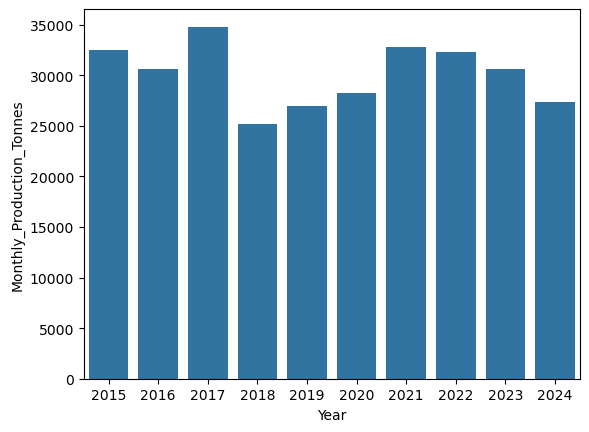

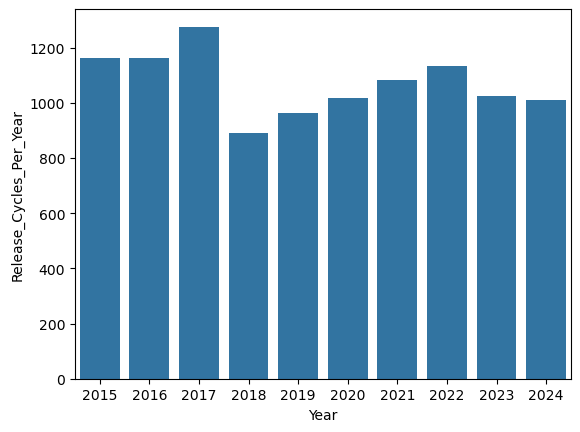

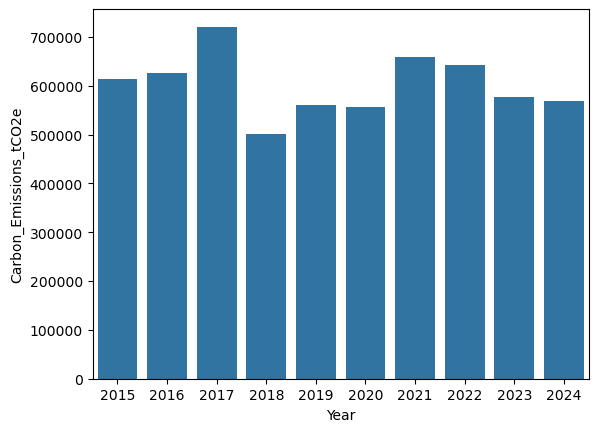

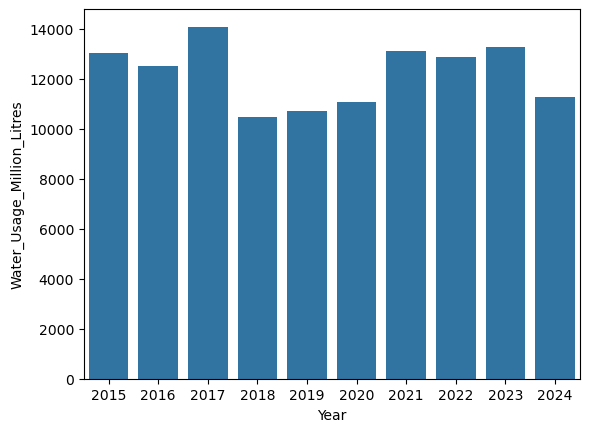

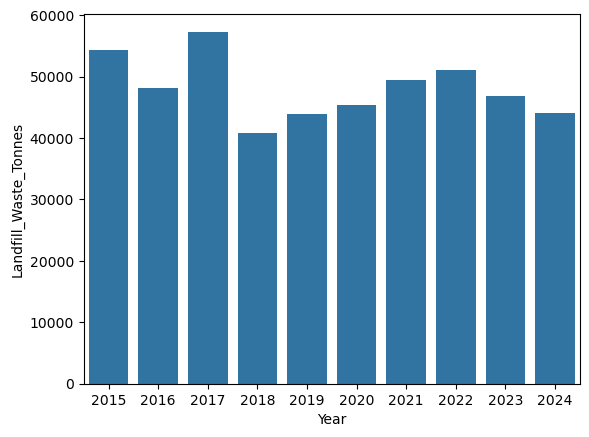

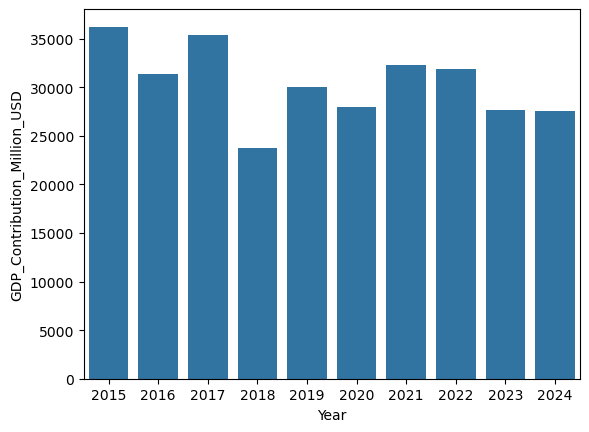

In [41]:
sns.barplot(data = zara_h1, x="Year", y="Monthly_Production_Tonnes")
plt.show()
sns.barplot(data = zara_h1, x="Year", y="Release_Cycles_Per_Year")
plt.show()
sns.barplot(data = zara_h1, x="Year", y="Carbon_Emissions_tCO2e")
plt.show()
sns.barplot(data = zara_h1, x="Year", y="Water_Usage_Million_Litres")
plt.show()
sns.barplot(data = zara_h1, x="Year", y="Landfill_Waste_Tonnes")
plt.show()
sns.barplot(data = zara_h1, x="Year", y="GDP_Contribution_Million_USD")
plt.show()

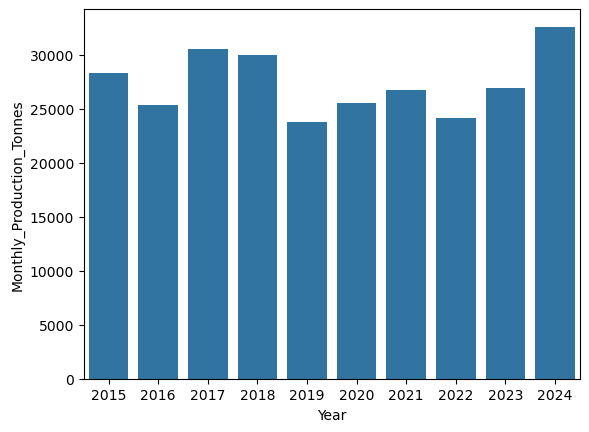

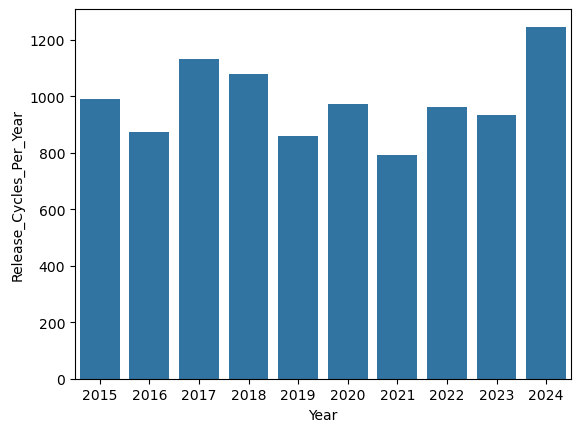

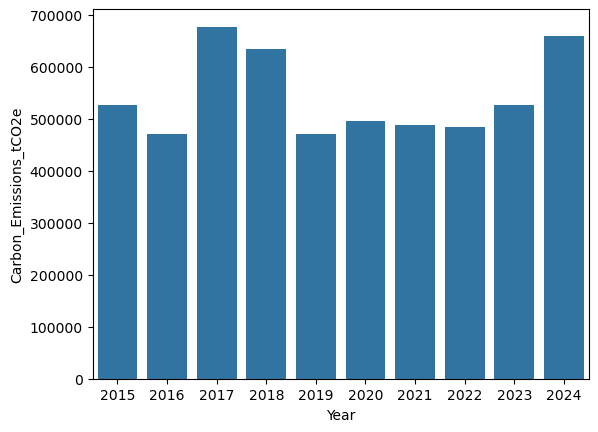

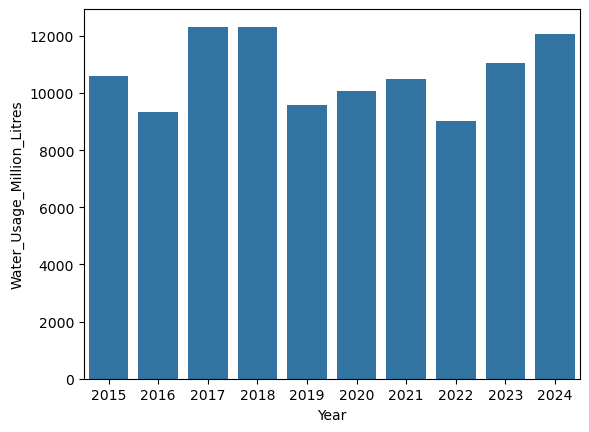

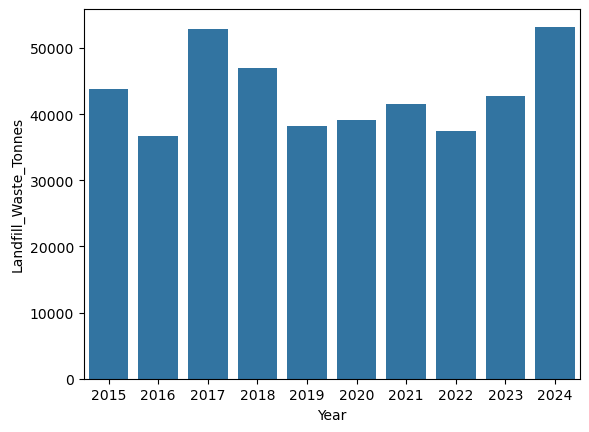

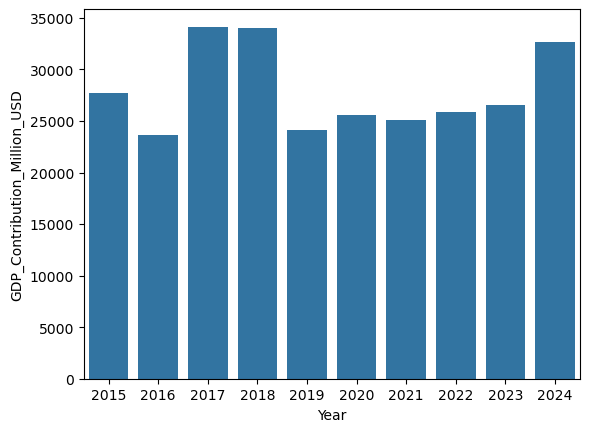

In [46]:
sns.barplot(data = shein_h1, x="Year", y="Monthly_Production_Tonnes")
plt.show()
sns.barplot(data = shein_h1, x="Year", y="Release_Cycles_Per_Year")
plt.show()
sns.barplot(data = shein_h1, x="Year", y="Carbon_Emissions_tCO2e")
plt.show()
sns.barplot(data = shein_h1, x="Year", y="Water_Usage_Million_Litres")
plt.show()
sns.barplot(data = shein_h1, x="Year", y="Landfill_Waste_Tonnes")
plt.show()
sns.barplot(data = shein_h1, x="Year", y="GDP_Contribution_Million_USD")
plt.show()

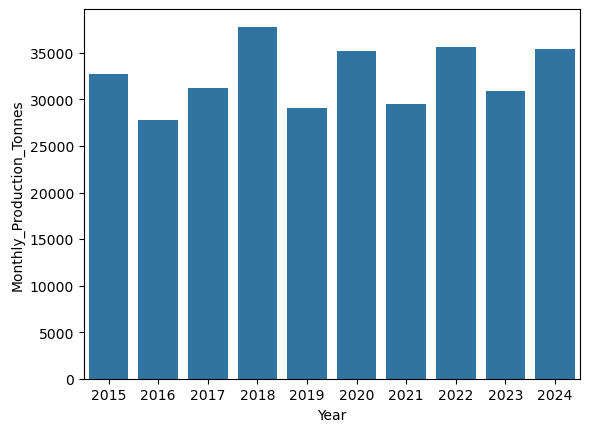

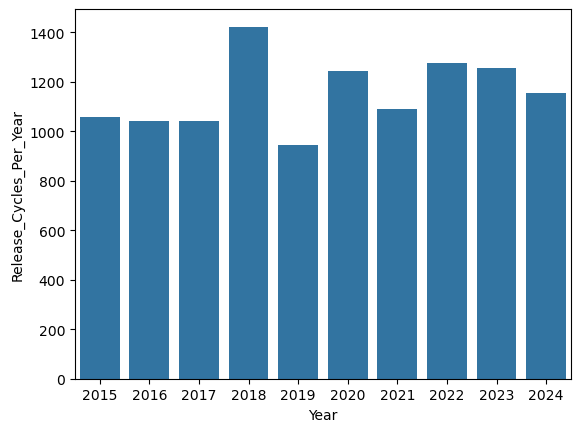

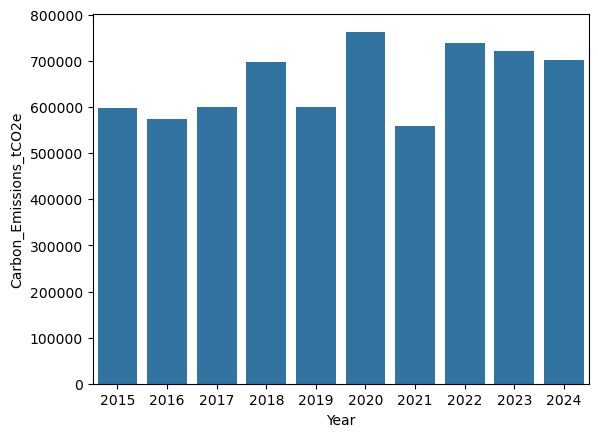

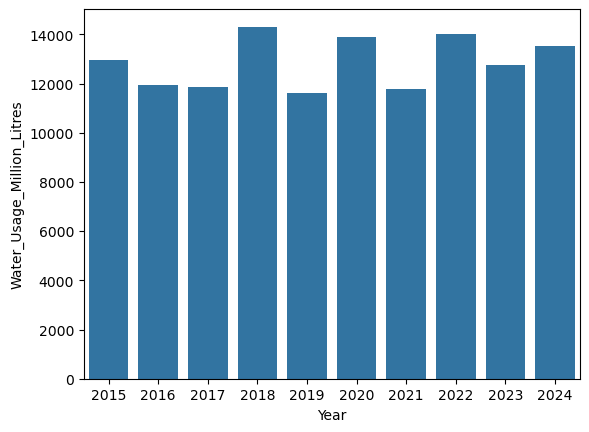

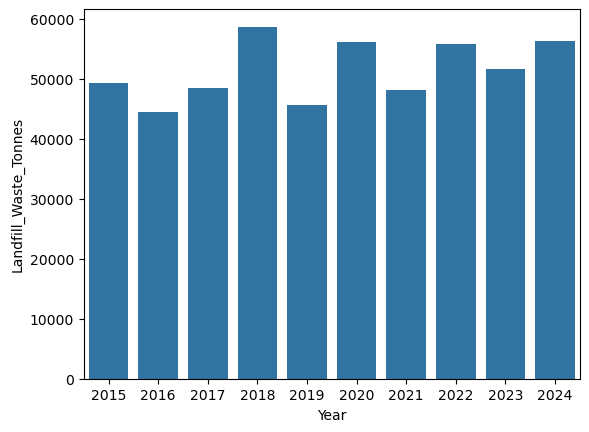

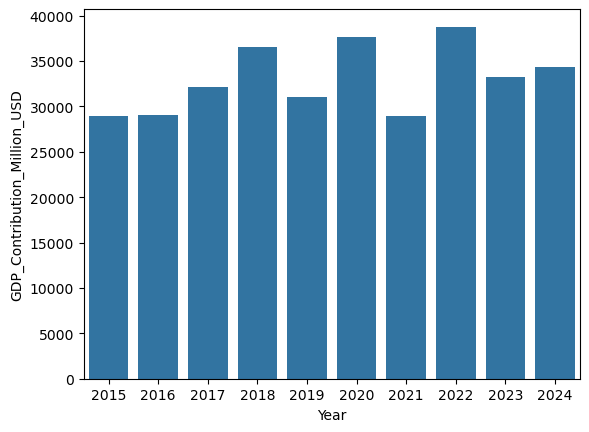

In [47]:
sns.barplot(data = hm_h1, x="Year", y="Monthly_Production_Tonnes")
plt.show()
sns.barplot(data = hm_h1, x="Year", y="Release_Cycles_Per_Year")
plt.show()
sns.barplot(data = hm_h1, x="Year", y="Carbon_Emissions_tCO2e")
plt.show()
sns.barplot(data = hm_h1, x="Year", y="Water_Usage_Million_Litres")
plt.show()
sns.barplot(data = hm_h1, x="Year", y="Landfill_Waste_Tonnes")
plt.show()
sns.barplot(data = hm_h1, x="Year", y="GDP_Contribution_Million_USD")
plt.show()

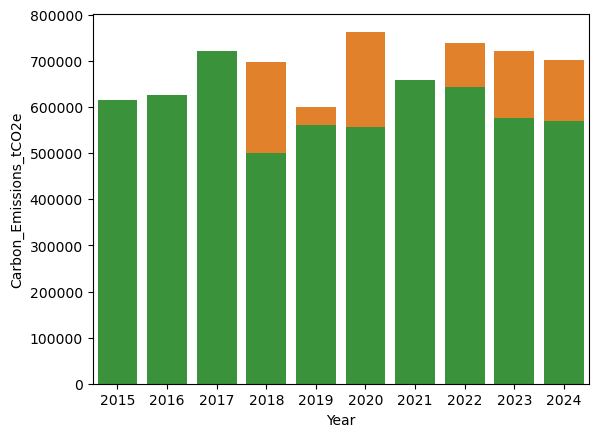

In [57]:
sns.barplot(data = shein_h1, x="Year", y="Carbon_Emissions_tCO2e")
sns.barplot(data = hm_h1, x="Year", y="Carbon_Emissions_tCO2e")
sns.barplot(data = zara_h1, x="Year", y="Carbon_Emissions_tCO2e")
plt.show()

## Hypothesis 2